В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn import preprocessing
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

from ml_homework.eda import get_columns_summary, get_target_column
from ml_homework.modeling import (
    linear_regression_coefficients,
    select_feature_columns,
    significant_ols_coefficients,
    train_linear_regression_show_rmse,
    train_ols_show_summary,
)
from ml_homework.paths import RAW_DATA_DIR

cars_df = pd.read_csv(RAW_DATA_DIR / "cars/cars.csv")
cars_df

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Mercedes,C-Class,2019,22000,Diesel,Automatic,First,16,1950,191,5,2900000
96,97,Toyota,Innova Crysta,2017,38000,Diesel,Manual,Second,13,2755,171,7,1400000
97,98,Ford,EcoSport,2018,26000,Petrol,Manual,Third,18,1497,121,5,750000
98,99,Hyundai,Verna,2019,24000,Petrol,Automatic,Second,17,1497,113,5,850000


# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [2]:
cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [3]:
cars_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Car_ID             100 non-null    int64
 1   Brand              100 non-null    str  
 2   Model              100 non-null    str  
 3   Year               100 non-null    int64
 4   Kilometers_Driven  100 non-null    int64
 5   Fuel_Type          100 non-null    str  
 6   Transmission       100 non-null    str  
 7   Owner_Type         100 non-null    str  
 8   Mileage            100 non-null    int64
 9   Engine             100 non-null    int64
 10  Power              100 non-null    int64
 11  Seats              100 non-null    int64
 12  Price              100 non-null    int64
dtypes: int64(8), str(5)
memory usage: 10.3 KB


In [4]:
cars_df.dtypes

Car_ID               int64
Brand                  str
Model                  str
Year                 int64
Kilometers_Driven    int64
Fuel_Type              str
Transmission           str
Owner_Type             str
Mileage              int64
Engine               int64
Power                int64
Seats                int64
Price                int64
dtype: object

In [5]:
cars_df.describe()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,50.500000,2018.39000,28150.000000,17.210000,1855.230000,158.130000,5.230000,1.574000e+06
std,29.011492,1.17116,9121.375716,3.309902,631.311475,76.968137,0.750151,1.000265e+06
min,1.000000,2016.00000,10000.000000,10.000000,999.000000,68.000000,4.000000,4.500000e+05
25%,25.750000,2017.75000,22000.000000,15.000000,1462.000000,103.000000,5.000000,7.000000e+05
50%,50.500000,2018.00000,27000.000000,17.000000,1774.000000,148.000000,5.000000,1.300000e+06
75%,75.250000,2019.00000,32000.000000,19.000000,2143.000000,187.000000,5.000000,2.500000e+06
max,100.000000,2021.00000,60000.000000,25.000000,4951.000000,396.000000,7.000000,4.000000e+06


In [6]:
numeric_cars_df = cars_df.select_dtypes(include="number")
numeric_cars_df

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
0,1,2018,50000,15,1498,108,5,800000
1,2,2019,40000,17,1597,140,5,1000000
2,3,2017,20000,10,4951,395,4,2500000
3,4,2020,30000,23,1248,74,5,600000
4,5,2016,60000,18,1999,194,5,850000
...,...,...,...,...,...,...,...,...
95,96,2019,22000,16,1950,191,5,2900000
96,97,2017,38000,13,2755,171,7,1400000
97,98,2018,26000,18,1497,121,5,750000
98,99,2019,24000,17,1497,113,5,850000


In [7]:
numeric_columns_list = numeric_cars_df.columns.to_list()
numeric_columns_list

['Car_ID',
 'Year',
 'Kilometers_Driven',
 'Mileage',
 'Engine',
 'Power',
 'Seats',
 'Price']

In [8]:
numeric_columns_count = numeric_cars_df.columns.size
numeric_columns_count

8

In [9]:
text_cars_df = cars_df.select_dtypes(include=["object", "string"])
text_cars_df

,Brand,Model,Fuel_Type,Transmission,Owner_Type
0,Toyota,Corolla,Petrol,Manual,First
1,Honda,Civic,Petrol,Automatic,Second
2,Ford,Mustang,Petrol,Automatic,First
3,Maruti,Swift,Diesel,Manual,Third
4,Hyundai,Sonata,Diesel,Automatic,Second
...,...,...,...,...,...
95,Mercedes,C-Class,Diesel,Automatic,First
96,Toyota,Innova Crysta,Diesel,Manual,Second
97,Ford,EcoSport,Petrol,Manual,Third
98,Hyundai,Verna,Petrol,Automatic,Second


In [10]:
categorical_columns_list = text_cars_df.columns.to_list()
categorical_columns_list

['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type']

In [11]:
categorical_columns_count = len(categorical_columns_list)
categorical_columns_count

5

In [12]:
cars_categorical_summary = get_columns_summary(categorical_columns_list, text_cars_df)

cars_categorical_summary

,column,nunique,unique_values
0,Brand,11,"[Toyota, Honda, Ford, Maruti, Hyundai, Tata, M..."
1,Model,58,"[Corolla, Civic, Mustang, Swift, Sonata, Nexon..."
2,Fuel_Type,2,"[Petrol, Diesel]"
3,Transmission,2,"[Manual, Automatic]"
4,Owner_Type,3,"[First, Second, Third]"


In [13]:
cars_numeric_summary = get_columns_summary(numeric_columns_list, numeric_cars_df)

cars_numeric_summary

,column,nunique,unique_values
0,Car_ID,100,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
1,Year,6,"[2018, 2019, 2017, 2020, 2016, 2021]"
2,Kilometers_Driven,18,"[50000, 40000, 20000, 30000, 60000, 35000, 450..."
3,Mileage,15,"[15, 17, 10, 23, 18, 20, 16, 12, 19, 25, 13, 2..."
4,Engine,36,"[1498, 1597, 4951, 1248, 1999, 1198, 2179, 999..."
5,Power,40,"[108, 140, 395, 74, 194, 76, 187, 190, 181, 15..."
6,Seats,3,"[5, 4, 7]"
7,Price,31,"[800000, 1000000, 2500000, 600000, 850000, 750..."


В наборі даних 8 числових і 5 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення): Fuel_Type і Transmission
- 2 мультикатегоріальні колонки без відношення порядку — Brand і Model
- 1 мультикатегоріальна колонка з відношенням порядку — Owner_Type, оскільки значення можна впорядкувати як First < Second < Third

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [14]:
X = cars_df.drop(columns=["Price", "Car_ID"]).copy()
y = cars_df["Price"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12
)

In [15]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (80, 11)
X_test: (20, 11)
y_train: (80,)
y_test: (20,)


**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [16]:
fuel_type_counts = X_train["Fuel_Type"].value_counts()
fuel_type_counts

Fuel_Type
Petrol    41
Diesel    39
Name: count, dtype: int64

In [17]:
transmission_type_counts = X_train["Transmission"].value_counts()
transmission_type_counts

Transmission
Automatic    49
Manual       31
Name: count, dtype: int64

In [18]:
fuel_type_codes = get_target_column(X_train, "Fuel_Type")

transmission_codes = get_target_column(X_train, "Transmission")

In [19]:
print(fuel_type_codes)
print(transmission_codes)

{'Petrol': 1, 'Diesel': 0}
{'Automatic': 1, 'Manual': 0}


In [20]:
X_train["fuel_type_code"] = X_train["Fuel_Type"].map(fuel_type_codes)

X_test["fuel_type_code"] = X_test["Fuel_Type"].map(fuel_type_codes)

X_train["transmission_code"] = X_train["Transmission"].map(transmission_codes)

X_test["transmission_code"] = X_test["Transmission"].map(transmission_codes)

In [21]:
enc = preprocessing.OneHotEncoder()

enc.fit(X_train[["Brand"]])

enc.categories_

[array(['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
        'Mercedes', 'Tata', 'Toyota', 'Volkswagen'], dtype=object)]

In [22]:
brand_train_encoded = enc.transform(X_train[["Brand"]]).toarray()
brand_test_encoded = enc.transform(X_test[["Brand"]]).toarray()

In [23]:
brand_columns = enc.categories_[0].tolist()

brand_columns

['Audi',
 'BMW',
 'Ford',
 'Honda',
 'Hyundai',
 'Mahindra',
 'Maruti',
 'Mercedes',
 'Tata',
 'Toyota',
 'Volkswagen']

In [24]:
X_train[brand_columns] = brand_train_encoded
X_test[brand_columns] = brand_test_encoded

In [25]:
X_train

,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,...,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen
83,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
55,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Mahindra,Scorpio,2018,45000,Diesel,Automatic,Second,15,2179,140,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
27,BMW,X3,2019,22000,Diesel,Automatic,Second,18,1995,187,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
X_train["Model"].to_list()

['T-Roc',
 'A5',
 'A6',
 'Vento',
 'GLC',
 'C-Class',
 'Q7',
 'Altroz',
 'A3',
 'XUV300',
 'S-Cross',
 'X3',
 'Q7',
 'Tiago',
 'Mustang',
 'Fortuner',
 'GLE',
 'Yaris',
 'Ranger',
 'Ranger',
 'Innova',
 'C-Class',
 'E-Class',
 'Innova Crysta',
 'C-Class',
 'Vitara',
 'Ameo',
 'WR-V',
 'Tigor',
 'Santro',
 'X5',
 'E-Class',
 'A6',
 'Altroz',
 'Venue',
 'XUV300',
 'Endeavour',
 '7 Series',
 'BR-V',
 'S-Cross',
 'Civic',
 'X5',
 'Elantra',
 'Sonata',
 '3 Series',
 'Passat',
 '3 Series',
 'EcoSport',
 'Verna',
 'Safari',
 'BR-V',
 'T-Roc',
 'EcoSport',
 'Mustang',
 '5 Series',
 'Passat',
 'Aspire',
 'Vitara',
 'Tigor',
 'Thar',
 'Ameo',
 'Camry',
 'A5',
 'Corolla',
 'A3',
 'Altroz',
 'WR-V',
 'Harrier',
 'Nexon',
 'Tiago',
 'Camry',
 'Verna',
 'GLA',
 'GLE',
 'Fortuner',
 'Swift',
 'Mustang',
 'Scorpio',
 'X3',
 '7 Series']

In [27]:
model_groups = {
    "Hatchback": ["Swift", "Polo", "Figo", "Altroz", "Santro", "Tiago"],
    "Sedan_Coupe": [
        "Corolla",
        "Civic",
        "Mustang",
        "Sonata",
        "A4",
        "C-Class",
        "City",
        "5 Series",
        "Verna",
        "Passat",
        "A6",
        "E-Class",
        "Aspire",
        "Elantra",
        "Ameo",
        "A3",
        "7 Series",
        "Yaris",
        "Tigor",
        "Camry",
        "Vento",
        "A5",
        "3 Series",
    ],
    "Utility": [
        "Nexon",
        "Scorpio",
        "X1",
        "Endeavour",
        "Creta",
        "Harrier",
        "Ertiga",
        "Tiguan",
        "Q3",
        "GLC",
        "Innova",
        "Thar",
        "X3",
        "Fortuner",
        "Safari",
        "Vitara",
        "WR-V",
        "GLE",
        "Ranger",
        "S-Cross",
        "BR-V",
        "T-Roc",
        "Q7",
        "X5",
        "GLA",
        "Venue",
        "XUV300",
        "Innova Crysta",
        "EcoSport",
    ],
}

In [28]:
model_group_mapping = {
    model: group for group, models in model_groups.items() for model in models
}

In [29]:
X_train["Model_Group"] = X_train["Model"].map(model_group_mapping)

X_test["Model_Group"] = X_test["Model"].map(model_group_mapping)

In [30]:
X_train["Model_Group"].value_counts()

Model_Group
Utility        37
Sedan_Coupe    36
Hatchback       7
Name: count, dtype: int64

In [31]:
X_test["Model_Group"].value_counts()

Model_Group
Utility        10
Sedan_Coupe     7
Hatchback       3
Name: count, dtype: int64

In [32]:
model_enc = preprocessing.OneHotEncoder()

model_enc.fit(X_train[["Model_Group"]])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infrequent

In [33]:
model_train_encoded = model_enc.transform(X_train[["Model_Group"]]).toarray()

model_test_encoded = model_enc.transform(X_test[["Model_Group"]]).toarray()

In [34]:
model_group_columns = model_enc.get_feature_names_out(["Model_Group"])

model_group_columns

array(['Model_Group_Hatchback', 'Model_Group_Sedan_Coupe',
       'Model_Group_Utility'], dtype=object)

In [35]:
X_train[model_group_columns] = model_train_encoded
X_test[model_group_columns] = model_test_encoded

In [36]:
numeric_columns = ["Year", "Kilometers_Driven", "Mileage", "Engine", "Power", "Seats"]

binary_columns = ["fuel_type_code", "transmission_code"]

input_cols = (
    numeric_columns + binary_columns + brand_columns + model_group_columns.tolist()
)

In [37]:
input_cols

['Year',
 'Kilometers_Driven',
 'Mileage',
 'Engine',
 'Power',
 'Seats',
 'fuel_type_code',
 'transmission_code',
 'Audi',
 'BMW',
 'Ford',
 'Honda',
 'Hyundai',
 'Mahindra',
 'Maruti',
 'Mercedes',
 'Tata',
 'Toyota',
 'Volkswagen',
 'Model_Group_Hatchback',
 'Model_Group_Sedan_Coupe',
 'Model_Group_Utility']

In [38]:
train_inputs = X_train[input_cols]
test_inputs = X_test[input_cols]

In [39]:
ordenc = preprocessing.OrdinalEncoder(
    categories=[["First", "Second", "Third"]]
)  # визначаємо порядок категорій
ordenc.fit(X_train[["Owner_Type"]])

X_train["Owner_Type_Codes"] = ordenc.transform(X_train[["Owner_Type"]])
X_test["Owner_Type_Codes"] = ordenc.transform(X_test[["Owner_Type"]])

In [40]:
model, train_predictions_encoded, test_predictions_encoded = (
    train_linear_regression_show_rmse(
        train_inputs,
        y_train,
        test_inputs,
        y_test,
    )
)

Train RMSE: 205315.5073000856
Test RMSE: 272548.86047670164


In [41]:
model.coef_, model.intercept_

(array([-9.80185211e+03, -7.83363803e+00, -3.45510435e+04, -5.74974417e+01,
         5.96243523e+03, -3.43639467e+04, -3.48960413e+05,  3.02587157e+05,
         7.73184978e+05,  7.71924221e+05, -2.48895714e+05, -2.37254827e+05,
        -4.87208667e+05, -5.92678660e+05, -4.33291509e+05,  7.37712599e+05,
        -2.38294740e+05,  1.61120322e+05, -2.06318002e+05,  9.05205241e+04,
        -1.13543158e+05,  2.30226339e+04]),
 np.float64(21516450.68268159))

In [42]:
np.append(model.coef_, model.intercept_)

array([-9.80185211e+03, -7.83363803e+00, -3.45510435e+04, -5.74974417e+01,
        5.96243523e+03, -3.43639467e+04, -3.48960413e+05,  3.02587157e+05,
        7.73184978e+05,  7.71924221e+05, -2.48895714e+05, -2.37254827e+05,
       -4.87208667e+05, -5.92678660e+05, -4.33291509e+05,  7.37712599e+05,
       -2.38294740e+05,  1.61120322e+05, -2.06318002e+05,  9.05205241e+04,
       -1.13543158e+05,  2.30226339e+04,  2.15164507e+07])

In [43]:
weights_df = linear_regression_coefficients(
    model,
    input_cols,
    include_intercept=True,
    sort_by_magnitude=False,
)
weights_df.style.format({"coefficient": "{:,.2f}"})

,feature,coefficient
0,Year,"-9,801.85"
1,Kilometers_Driven,-7.83
2,Mileage,"-34,551.04"
3,Engine,-57.50
4,Power,"5,962.44"
5,Seats,"-34,363.95"
6,fuel_type_code,"-348,960.41"
7,transmission_code,"302,587.16"
8,Audi,"773,184.98"
9,BMW,"771,924.22"


Очікуваний результат після трансформацій:

In [44]:
pd.set_option("display.max_columns", 100)
display(X_train.head()), display(X_test.head())

,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,fuel_type_code,transmission_code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Model_Group,Model_Group_Hatchback,Model_Group_Sedan_Coupe,Model_Group_Utility,Owner_Type_Codes
83,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Utility,0.0,0.0,1.0,1.0
55,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sedan_Coupe,0.0,1.0,0.0,0.0
26,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sedan_Coupe,0.0,1.0,0.0,0.0
54,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Sedan_Coupe,0.0,1.0,0.0,1.0
19,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,Utility,0.0,0.0,1.0,1.0


,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,fuel_type_code,transmission_code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Model_Group,Model_Group_Hatchback,Model_Group_Sedan_Coupe,Model_Group_Utility,Owner_Type_Codes
17,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Utility,0.0,0.0,1.0,1.0
41,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Hatchback,1.0,0.0,0.0,2.0
92,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Sedan_Coupe,0.0,1.0,0.0,1.0
14,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,Utility,0.0,0.0,1.0,0.0
68,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sedan_Coupe,0.0,1.0,0.0,2.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [45]:
numeric_X_train = X_train.select_dtypes(include="number")

In [46]:
concated_X_train_y_train = pd.concat([numeric_X_train, y_train.rename("Price")], axis=1)

In [47]:
correlation_matrix = concated_X_train_y_train.corr()

correlation_matrix

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,fuel_type_code,transmission_code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Model_Group_Hatchback,Model_Group_Sedan_Coupe,Model_Group_Utility,Owner_Type_Codes,Price
Year,1.000000,-0.708525,0.278559,-0.392764,-0.248442,-0.278755,0.248515,-0.200603,-0.256523,0.202517,-0.150454,-0.037437,-0.092099,0.181669,0.285094,-0.115157,0.248715,-0.219346,0.018255,0.412966,-0.158052,-0.076335,-0.014499,-0.233769
Kilometers_Driven,-0.708525,1.000000,-0.126621,0.101219,-0.060803,0.403656,-0.332351,-0.066491,0.095879,-0.247042,-0.009761,0.057372,0.154362,-0.040344,-0.190420,-0.091731,0.030399,0.368519,-0.137675,-0.253460,0.062886,0.080895,-0.001772,-0.083951
Mileage,0.278559,-0.126621,1.000000,-0.710516,-0.684705,-0.178619,-0.070112,-0.399164,-0.152701,-0.134105,-0.296480,0.358630,0.217406,0.029427,0.116389,-0.238489,0.347678,-0.201565,0.085114,0.383419,0.012892,-0.230158,0.026624,-0.638404
Engine,-0.392764,0.101219,-0.710516,1.000000,0.801638,0.167326,-0.174455,0.456296,0.085153,0.287119,0.184231,-0.154491,-0.182213,-0.024973,-0.193257,0.163871,-0.340051,0.234889,-0.165115,-0.339919,0.022552,0.170139,-0.196106,0.710561
Power,-0.248442,-0.060803,-0.684705,0.801638,1.000000,-0.139388,0.076357,0.586910,0.157050,0.372652,0.240501,-0.191810,-0.170966,-0.118021,-0.220984,0.280827,-0.316989,-0.040478,-0.148437,-0.327726,0.184240,0.001897,-0.204309,0.849137
Seats,-0.278755,0.403656,-0.178619,0.167326,-0.139388,1.000000,-0.412468,-0.070099,0.123674,-0.108079,-0.161451,0.200303,-0.086439,0.007738,-0.078379,-0.108079,-0.012748,0.348535,-0.094002,-0.094002,-0.376280,0.428725,-0.043849,0.000979
fuel_type_code,0.248515,-0.332351,-0.070112,-0.174455,0.076357,-0.412468,1.000000,-0.005775,-0.008336,-0.048475,0.109812,-0.161425,-0.007121,-0.235225,0.148511,-0.048475,0.066164,-0.008336,0.125010,0.213512,0.077915,-0.198747,0.281122,-0.110782
transmission_code,-0.200603,-0.066491,-0.399164,0.456296,0.586910,-0.070099,-0.005775,1.000000,0.265132,0.283188,-0.122816,-0.218620,0.031659,-0.170703,-0.112622,0.283188,-0.397609,-0.076974,0.155500,-0.389318,0.410016,-0.188475,0.005886,0.680731
Audi,-0.256523,0.095879,-0.152701,0.085153,0.157050,0.123674,-0.008336,0.265132,1.000000,-0.118678,-0.118678,-0.086066,-0.094916,-0.076472,-0.086066,-0.118678,-0.125988,-0.111111,-0.103221,-0.103221,0.201008,-0.142067,-0.203925,0.328858
BMW,0.202517,-0.247042,-0.134105,0.287119,0.372652,-0.108079,-0.048475,0.283188,-0.118678,1.000000,-0.126761,-0.091928,-0.101380,-0.081680,-0.091928,-0.126761,-0.134568,-0.118678,-0.110250,-0.110250,0.075541,-0.012893,0.009076,0.477522


In [48]:
price_correlations = (
    correlation_matrix["Price"].drop("Price").sort_values(key=abs, ascending=False)
)

price_correlations

Power                      0.849137
Engine                     0.710561
transmission_code          0.680731
Mileage                   -0.638404
BMW                        0.477522
Mercedes                   0.431606
Tata                      -0.341815
Model_Group_Hatchback     -0.338450
Audi                       0.328858
Owner_Type_Codes          -0.265537
Hyundai                   -0.263022
Maruti                    -0.249737
Year                      -0.233769
Honda                     -0.209779
Model_Group_Sedan_Coupe    0.193691
Mahindra                  -0.178627
Volkswagen                -0.158742
fuel_type_code            -0.110782
Kilometers_Driven         -0.083951
Toyota                    -0.023778
Ford                      -0.004592
Model_Group_Utility       -0.001455
Seats                      0.000979
Name: Price, dtype: float64

In [49]:
strong_price_correlations = price_correlations[price_correlations.abs() > 0.5]

strong_price_correlations

Power                0.849137
Engine               0.710561
transmission_code    0.680731
Mileage             -0.638404
Name: Price, dtype: float64

In [50]:
fig = px.imshow(
    correlation_matrix, text_auto=".2f", aspect="auto", title="Correlation Matrix"
)

fig.show()

Після аналізу кореляції числових ознак із цільовою змінною Price бачимо, що найбільший лінійний зв’язок із ціною мають:

Power	0.849137
Engine	0.710561
transmission_code	0.680731
Mileage	-0.638404

Тобто можемо зробити висновок, що зі збільшенням потужності автомобіля та об’єму двигуна його ціна зазвичай зростає. Позитивна кореляція transmission_code з ціною означає, що автомобілі з автоматичною трансмісією переважно мають вищу ціну.

Ознака Mileage має негативну кореляцію: автомобілі з більшою паливною ефективністю в цьому наборі даних переважно мають нижчу ціну.

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [51]:
X_train_numeric = X_train.select_dtypes(include="number").copy()
X_test_numeric = X_test.select_dtypes(include="number").copy()

In [52]:
X_train_numeric.head()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,fuel_type_code,transmission_code,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,Model_Group_Hatchback,Model_Group_Sedan_Coupe,Model_Group_Utility,Owner_Type_Codes
83,2019,22000,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
55,2018,28000,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
26,2018,28000,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
54,2017,32000,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
19,2017,26000,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [53]:
linear_model, train_predictions, test_predictions = train_linear_regression_show_rmse(
    X_train_numeric,
    y_train,
    X_test_numeric,
    y_test,
)

Train RMSE: 205234.07303034313
Test RMSE: 272045.33849927876


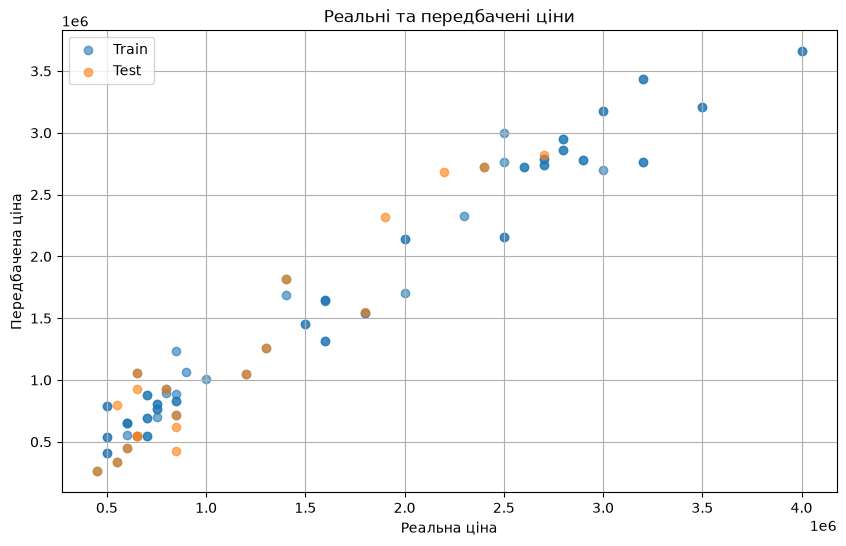

In [54]:
plt.figure(figsize=(10, 6))

plt.scatter(y_train, train_predictions, label="Train", alpha=0.6)
plt.scatter(y_test, test_predictions, label="Test", alpha=0.6)

plt.xlabel("Реальна ціна")
plt.ylabel("Передбачена ціна")
plt.title("Реальні та передбачені ціни")
plt.legend()
plt.grid()
plt.show()

Точки тренувального і тестового наборів загалом розташовані вздовж діагоналі ідеальних прогнозів, тому модель уловлює основну залежність між характеристиками автомобіля та його ціною. Водночас помітний розкид точок свідчить про значні помилки прогнозування. 

Розподіл тестових точок подібний до тренувальних, тому сильного перенавчання не видно.

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [55]:
scaler = preprocessing.StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_numeric),
    columns=X_train_numeric.columns,
    index=X_train_numeric.index,
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_numeric),
    columns=X_test_numeric.columns,
    index=X_test_numeric.index,
)

In [56]:
scaled_model, scaled_train_predictions, scaled_test_predictions = (
    train_linear_regression_show_rmse(
        X_train_scaled,
        y_train,
        X_test_scaled,
        y_test,
    )
)

Train RMSE: 205234.0730303429
Test RMSE: 272045.3384992774


In [57]:
scaled_weights_df = linear_regression_coefficients(scaled_model, X_train_scaled.columns)

scaled_weights_df.style.format({"coefficient": "{:,.2f}"})

,feature,coefficient
0,Power,"489,159.34"
1,BMW,"218,142.62"
2,Audi,"211,368.28"
3,Mercedes,"209,749.61"
4,fuel_type_code,"-179,041.78"
5,Hyundai,"-149,326.92"
6,Mahindra,"-145,979.09"
7,transmission_code,"145,429.08"
8,Maruti,"-123,240.37"
9,Mileage,"-120,223.17"


Після масштабування даних п’ять найбільших за абсолютною величиною коефіцієнтів мають ознаки Power, BMW, Audi, Mercedes і fuel_type_code. Отже, саме вони найсильніше впливають на прогноз моделі серед розглянутих ознак.
Найбільший додатний коефіцієнт має Power: збільшення потужності автомобіля на одне стандартне відхилення пов’язане зі збільшенням прогнозованої ціни приблизно на 489 тис. одиниць за незмінності інших характеристик.
Додатні коефіцієнти для BMW, Audi та Mercedes показують, що автомобілі цих марок мають вищу прогнозовану ціну порівняно з базовою маркою за інших однакових характеристик. Це узгоджується з тим, що ці бренди належать до дорожчого сегмента.
Для fuel_type_code використано кодування Diesel = 0, Petrol = 1. Від’ємний коефіцієнт означає, що перехід у напрямку категорії Petrol пов’язаний зі зменшенням прогнозованої ціни. Відповідно, дизельні автомобілі в цих даних у середньому мають вищу прогнозовану ціну за інших рівних умов.
Усі п’ять зазначених ознак також є статистично значущими на рівні значущості 0.05, оскільки їхні p-value менші за 0.05.

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [58]:
results, X_train_with_constant, X_test_with_constant = train_ols_show_summary(
    X_train_scaled, y_train, X_test_scaled
)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     67.33
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           4.19e-33
Time:                        18:41:31   Log-Likelihood:                -1092.1
No. Observations:                  80   AIC:                             2228.
Df Residuals:                      58   BIC:                             2281.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [59]:
train_predictions = results.predict(X_train_with_constant)
test_predictions = results.predict(X_test_with_constant)

In [60]:
train_rmse = root_mean_squared_error(y_train, train_predictions)

test_rmse = root_mean_squared_error(y_test, test_predictions)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train RMSE: 205234.07303034296
Test RMSE: 272045.3384992772


In [61]:
significant_coefficients, significant_features = significant_ols_coefficients(results)

Статистично значущі ознаки: ['Audi', 'Mercedes', 'BMW', 'Power', 'Hyundai', 'Mahindra', 'Maruti', 'fuel_type_code', 'transmission_code', 'Ford', 'Volkswagen', 'Tata', 'Honda']


In [62]:
significant_coefficients.style.format({"coefficient": "{:.2f}", "p_value": "{:.10f}"})

,coefficient,p_value
Audi,211368.28,0.0000000040
Mercedes,209749.61,0.0000000055
BMW,218142.62,0.0000000065
Power,489159.34,0.0000000066
Hyundai,-149326.92,0.0000027959
Mahindra,-145979.09,0.0000116936
Maruti,-123240.37,0.0001052786
fuel_type_code,-179041.78,0.0001765079
transmission_code,145429.08,0.0024827330
Ford,-105145.74,0.0028793129


**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [63]:
X_train_significant, X_test_significant = select_feature_columns(
    X_train_scaled, X_test_scaled, significant_features
)

In [64]:
(
    significant_results,
    X_train_significant_with_constant,
    X_test_significant_with_constant,
) = train_ols_show_summary(X_train_significant, y_train, X_test_significant)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                     99.02
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           5.11e-38
Time:                        18:41:31   Log-Likelihood:                -1100.6
No. Observations:                  80   AIC:                             2229.
Df Residuals:                      66   BIC:                             2263.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.81e+0

Попередні показники R2 і Adj. R-squared:

R-squared:                       0.961
Adj. R-squared:                  0.946

Поточні показники R2 і Adj. R-squared:

R-squared:                       0.951
Adj. R-squared:                  0.942


Отже після відбору лише статистично значущих ознак R2 зменшився з 0.961 до 0.951, а Adjusted R2 — з 0.946 до 0.942. Зменшення є незначним: скорочена модель усе ще пояснює приблизно 95.1% варіації цільової змінної. Отже, вилучені ознаки давали лише невеликий додатковий внесок у якість підгонки моделі.
За значеннями R2 та Adjusted R2 повна модель трохи краща, однак скорочена модель є простішою та майже не поступається їй за пояснювальною здатністю. Тому за умови подібної якості на тестових даних доцільно обрати скорочену модель.


**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [65]:
coefficients_025, features_025 = significant_ols_coefficients(
    results,
    alpha=0.25,
)

Статистично значущі ознаки: ['Audi', 'Mercedes', 'BMW', 'Power', 'Hyundai', 'Mahindra', 'Maruti', 'fuel_type_code', 'transmission_code', 'Ford', 'Volkswagen', 'Tata', 'Honda', 'Mileage', 'Model_Group_Sedan_Coupe', 'Kilometers_Driven']


In [66]:
coefficients_025.style.format({"coefficient": "{:.2f}", "p_value": "{:.10f}"})

,coefficient,p_value
Audi,211368.28,0.0000000040
Mercedes,209749.61,0.0000000055
BMW,218142.62,0.0000000065
Power,489159.34,0.0000000066
Hyundai,-149326.92,0.0000027959
Mahindra,-145979.09,0.0000116936
Maruti,-123240.37,0.0001052786
fuel_type_code,-179041.78,0.0001765079
transmission_code,145429.08,0.0024827330
Ford,-105145.74,0.0028793129


In [67]:
X_train_025, X_test_025 = select_feature_columns(
    X_train_scaled, X_test_scaled, features_025
)

In [68]:
results_025, X_train_025_with_constant, X_test_025_with_constant = (
    train_ols_show_summary(X_train_025, y_train, X_test_025)
)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     94.49
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           9.79e-38
Time:                        18:41:31   Log-Likelihood:                -1092.7
No. Observations:                  80   AIC:                             2219.
Df Residuals:                      63   BIC:                             2260.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

Показники R2 і Adj. R-squared завдання 8:

R-squared:                       0.961
Adj. R-squared:                  0.946

Показники R2 і Adj. R-squared завдання 9:

R-squared:                       0.951
Adj. R-squared:                  0.942


Показники R2 і Adj. R-squared завдання 10:

R-squared:                       0.960
Adj. R-squared:                  0.950

Модель із завдання 10 має R^2 = 0.960, що майже дорівнює результату повної моделі із завдання 8 0.961 і перевищує результат скороченої моделі із завдання 9  - 0.951.
Водночас її Adjusted R^2 = 0.950 є найвищим серед трьох моделей. Це означає, що модель добре пояснює цільову змінну з урахуванням кількості використаних ознак.
Модель із завдання 10 використовує менше ознак, ніж повна модель, але більше, ніж модель із завдання 9. Отже, вона забезпечує найкращий баланс між пояснювальною здатністю та складністю. Попередньо для використання доцільно обрати саме модель із завдання 10.